In [1]:
# Import von Bibliotheken
from datasets import load_dataset
import urllib.request
import io,re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
# Einlesen weiterer Bibliotheken
import os
# Deutsche Stopwörter laden
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = stopwords.words('german')

from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
!pip install sentence-transformers

[nltk_data] Downloading package punkt to /home/haloh001/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/haloh001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
!pip install "transformers==4.47.1" "sentence-transformers"
from sentence_transformers import SentenceTransformer

In [3]:
!pip install bertopic
!pip uninstall -y umap umap-learn
!pip install umap-learn
from umap import UMAP
import hdbscan
import umap
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

Found existing installation: umap-learn 0.5.12
Uninstalling umap-learn-0.5.12:
  Successfully uninstalled umap-learn-0.5.12
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)


In [4]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [5]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
#CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [6]:
# durchschnittliche Anzahl der Länge jedes einzelnen Dokuments pro Partei VOR BEREINIGUNG
# zur Orientierung die Anzahl der Absätze mit einer Länge von max. 100 Zeichen
durchschnitt_CDU = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU = len([i for i in CDU_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm: ",durchschnitt_CDU)
print("Anzahl aller Absätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU)
print("-----")
durchschnitt_SPD = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD = len([i for i in SPD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm: ",durchschnitt_SPD)
print("Anzahl aller Absätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD)
print("-----")
durchschnitt_Linke = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke = len([i for i in Linke_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm: ",durchschnitt_Linke)
print("Anzahl aller Absätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke)
print("-----")
durchschnitt_AfD = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD = len([i for i in AfD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm: ",durchschnitt_AfD)
print("Anzahl aller Absätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD)
print("-----")
durchschnitt_Grüne = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne = len([i for i in Grüne_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne)
print("Anzahl aller Absätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne)
print("-----")
durchschnitt_FDP = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP = len([i for i in FDP_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm: ",durchschnitt_FDP)
print("Anzahl aller Absätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP)
print("-----")

Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm:  257.4
Anzahl aller Absätze:  795
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  153
-----
Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm:  465.3
Anzahl aller Absätze:  444
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  15
-----
Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm:  380.0
Anzahl aller Absätze:  665
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  30
-----
Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm:  299.6
Anzahl aller Absätze:  717
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
-----
Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm:  649.5
Anzahl aller Absätze:  583
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  7
-----
Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm:  751.7
Anzahl aller Absätze:  200
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  1
-----


In [7]:
# für das Wahlprogramm der FDP

FDP_text = [text for text in FDP_text if len(text) >= 60]
durchschnitt_FDP_neu = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP_neu = len([i for i in FDP_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu, "(alt: ",durchschnitt_FDP, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu, "(alt: ",anzahl_FDP, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm:  755.3 (alt:  751.7 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  0 (alt:  1 )


In [8]:
# Herauslöschen der unerwünschten Texte
# wir gehen nicht nach Länge, da teils längere Text inhaltslos sind und kürzere nicht
# manuelles Löschen bevorzugt statt pauschales Löschen z.B. "alles < 60 Zeichen"

# einzelne Löschen von Indizes verschiebt diese, daher der Weg über eine Liste
loesch_indizes = {1, 8, 11, 13, 22, 33, 34, 35, 52}

# Neue Liste erstellen ohne die unerwünschten Indizes
SPD_text = [element for index, element in enumerate(SPD_text) if index not in loesch_indizes]

durchschnitt_SPD_neu = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD_neu = len([i for i in SPD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu, "(alt: ",durchschnitt_SPD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu, "(alt: ",anzahl_SPD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6 (alt:  465.3 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6 (alt:  15 )


In [9]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {13, 75, 93, 101, 104, 106, 115}
Linke_text = [element for index, element in enumerate(Linke_text) if index not in loesch_indizes]

durchschnitt_Linke_neu = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke_neu = len([i for i in Linke_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu, "(alt: ",durchschnitt_Linke, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu, "(alt: ",anzahl_Linke, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5 (alt:  380.0 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23 (alt:  30 )


In [10]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {8, 10, 13, 16, 23, 24}
Grüne_text = [element for index, element in enumerate(Grüne_text) if index not in loesch_indizes]

durchschnitt_Grüne_neu = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne_neu = len([i for i in Grüne_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu, "(alt: ",durchschnitt_Grüne, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu, "(alt: ",anzahl_Grüne, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2 (alt:  649.5 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4 (alt:  7 )


In [11]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {0,}
AfD_text = [element for index, element in enumerate(AfD_text) if index not in loesch_indizes]

durchschnitt_AfD_neu = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD_neu = len([i for i in AfD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu, "(alt: ",durchschnitt_AfD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu, "(alt: ",anzahl_AfD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8 (alt:  299.6 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108 (alt:  108 )


In [12]:
# Anderer Ansatz: Herauslöschen der Strings unter 90 Zeichen
# diese fassen im Vorfeld die Punkte zusammen, die anschließend ausführlich in längeren Fließtexten samt bullet points folgen

CDU_text = [text for text in CDU_text if len(text) >= 89]

durchschnitt_CDU_neu = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU_neu = len([i for i in CDU_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu, "(alt: ",durchschnitt_CDU, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu, "(alt: ",anzahl_CDU, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm:  308.6 (alt:  257.4 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4 (alt:  153 )


In [13]:
# aktualisierte durchschnittliche Länge jedes einzelnen Dokuments pro Partei NACH BEREINIGUNG
print("Durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu)
print("Anzahl der Gesamtabsätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_CDU_neu/len(CDU_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu)
print("Anzahl der Gesamtabsätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_SPD_neu/len(SPD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu)
print("Anzahl der Gesamtabsätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Linke_neu/len(Linke_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu)
print("Anzahl der Gesamtabsätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_AfD_neu/len(AfD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu)
print("Anzahl der Gesamtabsätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Grüne_neu/len(Grüne_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu)
print("Anzahl der Gesamtabsätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_FDP_neu/len(FDP_text)*100,2))
print("-----")

Durchschnittliche Länge eines Absatzes im CDU-Programm:  308.6
Anzahl der Gesamtabsätze:  646
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  0.62
-----
Durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6
Anzahl der Gesamtabsätze:  435
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  1.38
-----
Durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5
Anzahl der Gesamtabsätze:  658
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  3.5
-----
Durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8
Anzahl der Gesamtabsätze:  716
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  15.08
-----
Durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2
Anzahl der Gesamtabsätze:  577
Anzahl 

In [14]:
# SCHRITT 2: ZUSAMMENFASSEN DER BULLET POINTS UND ANHÄNGEN DIESER 'GESAMMELTEN BULLET POINTS'
#            an an den vorherigen (normalen Fließtext-)Absatz (für Ziel 2)

# zunächst die Ermittlung wie viele Absätze 'bullet points' sind, d.h. mit Sonderzeichen wie Bindestrich oder '•' beginnen

print(f"Gefundene Strings im CDU/CSU-Wahlprogramm: {len(s := [t for t in CDU_text if t and not t[0].isalpha()])} von {len(CDU_text)} ({(len(s)/len(CDU_text)*100 if CDU_text else 0):.2f}%)")
print(f"Gefundene Strings im SPD-Wahlprogramm: {len(s := [t for t in SPD_text if t and not t[0].isalpha()])} von {len(SPD_text)} ({(len(s)/len(SPD_text)*100 if SPD_text else 0):.2f}%)")
print(f"Gefundene Strings im Linke-Wahlprogramm: {len(s := [t for t in Linke_text if t and not t[0].isalpha()])} von {len(Linke_text)} ({(len(s)/len(Linke_text)*100 if Linke_text else 0):.2f}%)")
print(f"Gefundene Strings im Grüne-Wahlprogramm: {len(s := [t for t in Grüne_text if t and not t[0].isalpha()])} von {len(Grüne_text)} ({(len(s)/len(Grüne_text)*100 if Grüne_text else 0):.2f}%)")
print(f"Gefundene Strings im AfD-Wahlprogramm: {len(s := [t for t in AfD_text if t and not t[0].isalpha()])} von {len(AfD_text)} ({(len(s)/len(AfD_text)*100 if AfD_text else 0):.2f}%)")
print(f"Gefundene Strings im FDP-Wahlprogramm: {len(s := [t for t in FDP_text if t and not t[0].isalpha()])} von {len(FDP_text)} ({(len(s)/len(FDP_text)*100 if FDP_text else 0):.2f}%)")


Gefundene Strings im CDU/CSU-Wahlprogramm: 545 von 646 (84.37%)
Gefundene Strings im SPD-Wahlprogramm: 16 von 435 (3.68%)
Gefundene Strings im Linke-Wahlprogramm: 481 von 658 (73.10%)
Gefundene Strings im Grüne-Wahlprogramm: 0 von 577 (0.00%)
Gefundene Strings im AfD-Wahlprogramm: 216 von 716 (30.17%)
Gefundene Strings im FDP-Wahlprogramm: 0 von 199 (0.00%)


In [15]:
# in anderem Notebook ermittelte Durchschnittswerte
cdu_avg_length = 281
spd_avg_length = 465
linke_avg_length = 380
grüne_avg_length = 650
afd_avg_length = 300
fdp_avg_length = 752

In [16]:
# Ermittlung der Kehrtwerte, die als Gewichtungsfaktoren für die spätere Kategorie-Zuteilung herangezogen werden

# für 'CDU_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in CDU_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(cdu_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_cdu = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_cdu.append(x)

In [17]:
# für 'SPD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in SPD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(spd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_spd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_spd.append(x)

In [18]:
# für 'Linke_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Linke_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(linke_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_linke = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_linke.append(x)

In [19]:
# für 'Grüne_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Grüne_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(grüne_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_grüne = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_grüne.append(x)

In [20]:
# für 'AfD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in AfD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(afd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_afd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_afd.append(x)

In [21]:
# für 'FDP_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in FDP_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(fdp_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_fdp = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_fdp.append(x)

In [22]:
# Liste wieder laden mit den eingelesenen und 'vorbereiteten' (um Phrasen, Einleitungen, Begrüßung usw. bereinigt...)

with open("text_liste_CDU_1_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_1_clean = json.load(f)

with open("text_liste_CDU_2_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_2_clean = json.load(f)

with open("text_liste_CDU_3_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_3_clean = json.load(f)

with open("text_liste_CDU_4_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_4_clean = json.load(f)

with open("text_liste_CDU_5_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_5_clean = json.load(f)

with open("text_liste_SPD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_1_clean = json.load(f)

with open("text_liste_SPD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_2_clean = json.load(f)

with open("text_liste_SPD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_3_clean = json.load(f)

with open("text_liste_SPD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_4_clean = json.load(f)

with open("text_liste_SPD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_5_clean = json.load(f)

with open("text_liste_Linke_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_1_clean = json.load(f)

with open("text_liste_Linke_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_2_clean = json.load(f)

with open("text_liste_Linke_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_3_clean = json.load(f)

with open("text_liste_Linke_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_4_clean = json.load(f)

with open("text_liste_Linke_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_5_clean = json.load(f)

with open("text_liste_Grüne_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_1_clean = json.load(f)

with open("text_liste_Grüne_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_2_clean = json.load(f)

with open("text_liste_Grüne_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_3_clean = json.load(f)

with open("text_liste_Grüne_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_4_clean = json.load(f)

with open("text_liste_Grüne_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_5_clean = json.load(f)

with open("text_liste_AfD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_1_clean = json.load(f)

with open("text_liste_AfD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_2_clean = json.load(f)

with open("text_liste_AfD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_3_clean = json.load(f)

with open("text_liste_AfD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_4_clean = json.load(f)

with open("text_liste_AfD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_5_clean = json.load(f)

with open("text_liste_FDP_1_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_1_clean = json.load(f)

with open("text_liste_FDP_2_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_2_clean = json.load(f)

with open("text_liste_FDP_3_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_3_clean = json.load(f)

with open("text_liste_FDP_4_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_4_clean = json.load(f)

with open("text_liste_FDP_5_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_5_clean = json.load(f)

In [23]:
# Wahlprogramme nicht in chunks aufteilen; Annahme: Absätze behandeln i.d.R. ein Thema
CDU_WP_chunks = CDU_text
SPD_WP_chunks = SPD_text
Grüne_WP_chunks = Grüne_text
AfD_WP_chunks = AfD_text
Linke_WP_chunks = Linke_text
FDP_WP_chunks = FDP_text

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_WP_chunks_len = len(CDU_WP_chunks)
SPD_WP_chunks_len = len(SPD_WP_chunks)
Grüne_WP_chunks_len = len(Grüne_WP_chunks)
AfD_WP_chunks_len = len(AfD_WP_chunks)
Linke_WP_chunks_len = len(Linke_WP_chunks)
FDP_WP_chunks_len = len(FDP_WP_chunks)

CDU_anteil = kehrwert_cdu
SPD_anteil = kehrwert_spd
Linke_anteil = kehrwert_linke
Grüne_anteil = kehrwert_grüne
AfD_anteil = kehrwert_afd
FDP_anteil = kehrwert_fdp

In [24]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/1432 [00:00<?, ?it/s]

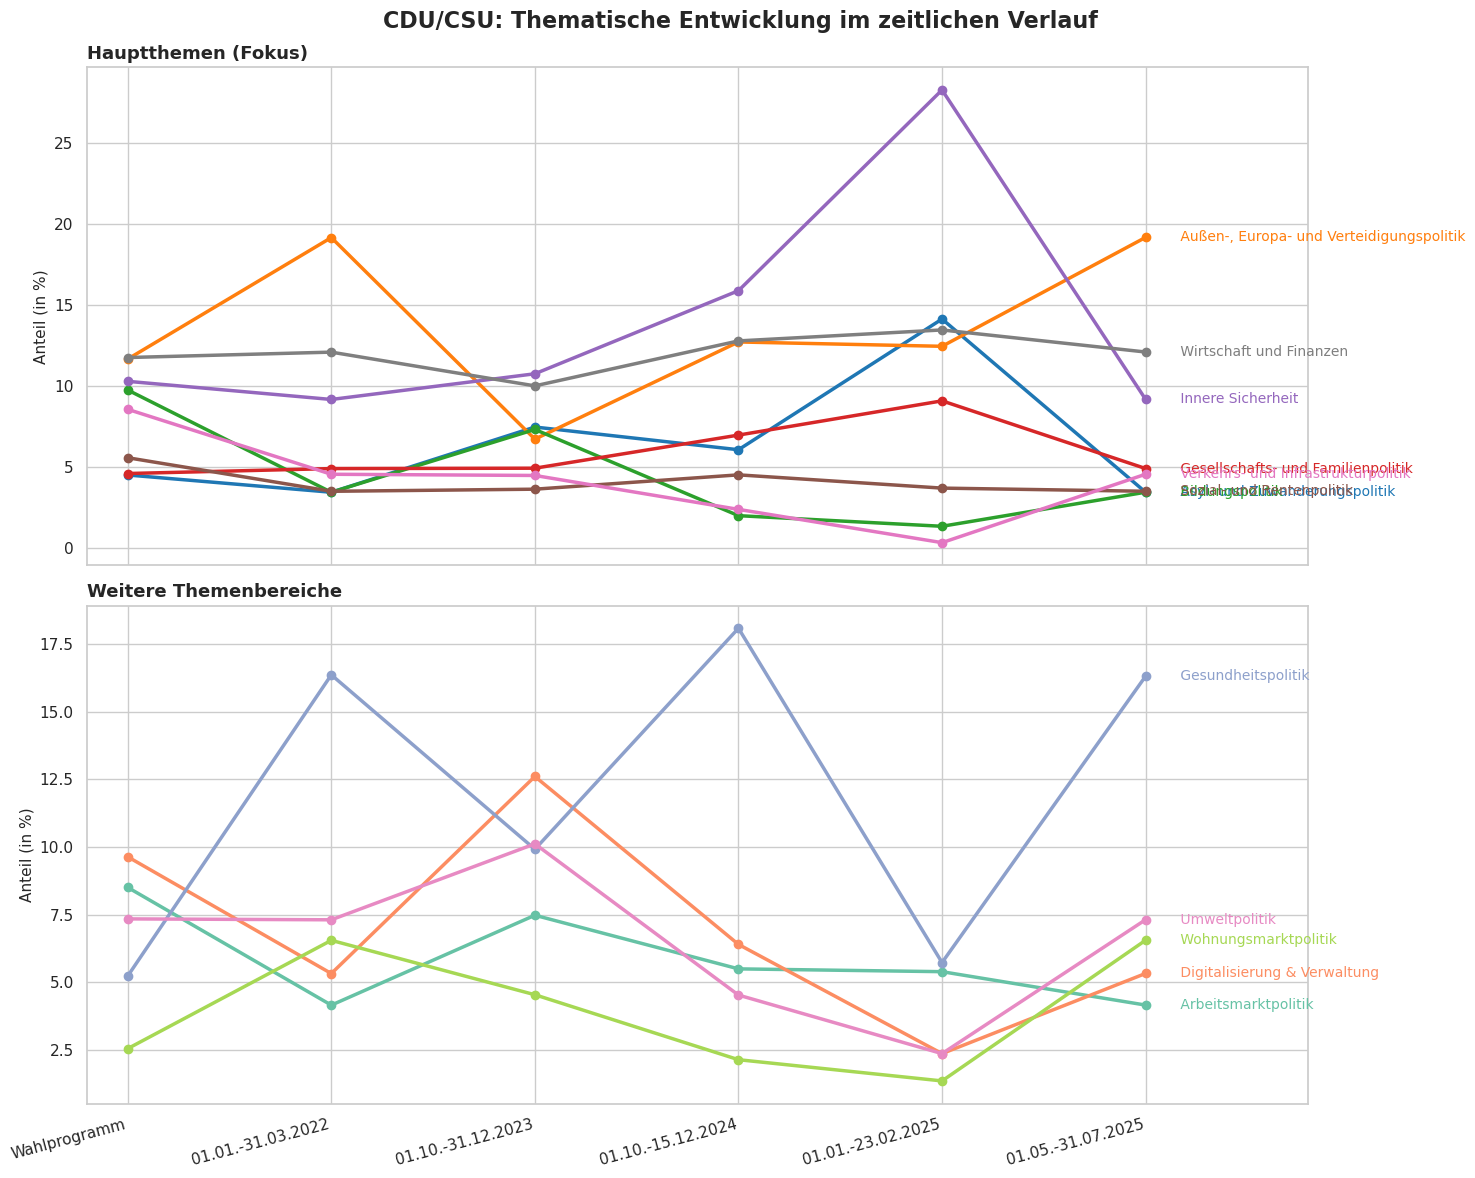

In [25]:
####### TEST 1   # Chunk-Größe 800

# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

stoppwörter = ['90', '90die', 'aber', 'abgeordnete', 'absolut', 'afd', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also',
    'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer', 'anderes', 'anderm', 'andern', 'anscheinend',
    'anderr', 'anders', 'antrag', 'arbeiten', 'auch', 'ausschüsse', 'auf', 'aus', 'basis', 'bei', 'bevölkerung',
    'bin', 'bis', 'bisher', 'bist', 'bitte', 'brauchen', 'bundesregierung', 'bundestag', 'bundespräsidenten', 'bundespräsident', 'bündnis', 'cdu', 'cducsu',
    'csu', 'da', 'dafür', 'damen', 'damit', 'dank', 'danke', 'dann', 'das', 'dass', 'dasselbe', 'dazu', 'dr',
    'daß', 'debatte', 'definitiv', 'dein', 'deine', 'deinem', 'deinen', 'deiner', 'deines', 'dem', 'demokraten', 'demokratie', 'demselben', 'den',
    'denn', 'denselben', 'der', 'derer', 'derselbe', 'derselben', 'des', 'desselben', 'dessen', 'deutschen', 'deutsch', 'deswegen', 'deshalb',
    'deutschland', 'dich', 'die', 'dies', 'diese', 'dieselbe', 'dieselben', 'diesem', 'diesen', 'dieser', 'dieses',
    'dir', 'doch', 'dort', 'du', 'durch', 'eben', 'ebene', 'ebenen', 'ein', 'eine', 'einem', 'einen', 'einer', 'ende',
    'eines', 'einig', 'einige', 'einigem', 'einigen', 'einiger', 'einiges', 'einmal', 'er', 'es', 'etwas', 'euch',
    'euer', 'eure', 'eurem', 'euren', 'eurer', 'eures', 'euro', 'faktisch', 'fdp', 'frage', 'fraktionbündnis', 'fraktion', 'frau', 'für', 'ganz', 'geehrte',
    'gegen', 'geht', 'generationen', 'gerecht', 'gerechtigkeit', 'gerade', 'gesellschaft', 'gewesen', 'grünenfraktion', 'gewissermaßen', 'gewissenhaft', 'gibt', 'gott', 'grüne', 'grünen', 'gut', 'hab', 'habe', 'haben',
    'hat', 'hatte', 'hatten', 'helfe', 'herr', 'herren', 'heute', 'hier', 'hin', 'hinter', 'hätte', 'ich', 'ihm',
    'ihn', 'ihnen', 'ihr', 'ihre', 'ihrem', 'ihren', 'ihrer', 'ihres', 'im', 'immer', 'in', 'indem', 'ins', 'international',
    'ist', 'ja', 'jahr', 'jahren', 'jede', 'jedem', 'jeden', 'jeder', 'jedes', 'jene', 'jenem', 'jenen', 'jener', 'jedermann',
    'jenes', 'jetzt', 'kann', 'kein', 'keine', 'keinem', 'keinen', 'keiner', 'keines', 'kollege', 'kollegen', 'kommen',
    'kollegin', 'kolleginnen', 'können', 'könnte', 'land', 'letzte', 'letzten', 'liebe', 'liegen', 'linke', 'machen', 'mal',
    'man', 'manche', 'manchem', 'manchen', 'mancher', 'manches', 'maßnahme', 'maßnahmen', 'mehr', 'mein', 'meine', 'möchte',
    'meinem', 'meinen', 'meiner', 'meines', 'menschen', 'merz', 'mich', 'milliarden', 'minister', 'ministerin', 'nächste', 'nächsten',
    'mir', 'mit', 'muss', 'musste', 'müssen', 'nach', 'name', 'namen', 'natürlich', 'nicht', 'nichts', 'noch', 'nun', 'nur', 'offensichtlich',
    'ob', 'oder', 'ohne', 'parlament', 'partei', 'praktisch', 'prozent', 'prozesse', 'präsident', 'präsidentin', 'quasi', 'rede', 'redner', 'rednerin',
    'regierung', 'sagen', 'scheinbar', 'schon', 'schritte', 'sehr', 'sein', 'seine', 'seinem', 'seinen', 'seiner', 'seines',
    'selbst', 'setzen', 'sich', 'sie', 'sind', 'sitzungswochen', 'so', 'solche', 'solchem', 'solchen', 'solcher', 'solches', 'soll', 'schwöre',
    'sollte', 'sondern', 'sonst', 'sowie', 'spd', 'tatsächlich', 'um', 'und', 'union', 'uns', 'unser', 'unsere', 'unserem', 'vertrauensfrage', 'vertrauen',
    'unseren', 'unseres', 'unter', 'viel', 'viele', 'vielen', 'vielleicht', 'vollkommen', 'vom', 'von', 'vor', 'wahl', 'wahlkreise', 'wahr', 'war', 'waren', 'warst', 'was',
    'weg', 'weihnachten', 'weil', 'weiter', 'welche', 'welchem', 'welchen', 'welcher', 'welches', 'weltweit', 'welt', 'wenden',
    'weltweiten', 'weniger', 'wenn', 'werde', 'werden', 'wie', 'wieder', 'will', 'wir', 'wird', 'wirklich', 'wirst', 'wo',
    'wollen', 'wollte', 'wort', 'während', 'wünsche', 'würde', 'würden', 'ziel', 'ziele', 'zu', 'zum', 'zur',
    'zwar', 'zwischen', 'über']

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Embedding-Modell und Vektorisier definieren

!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# TEST 2  #  - Chunk-Größe  1200

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1200,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/987 [00:00<?, ?it/s]

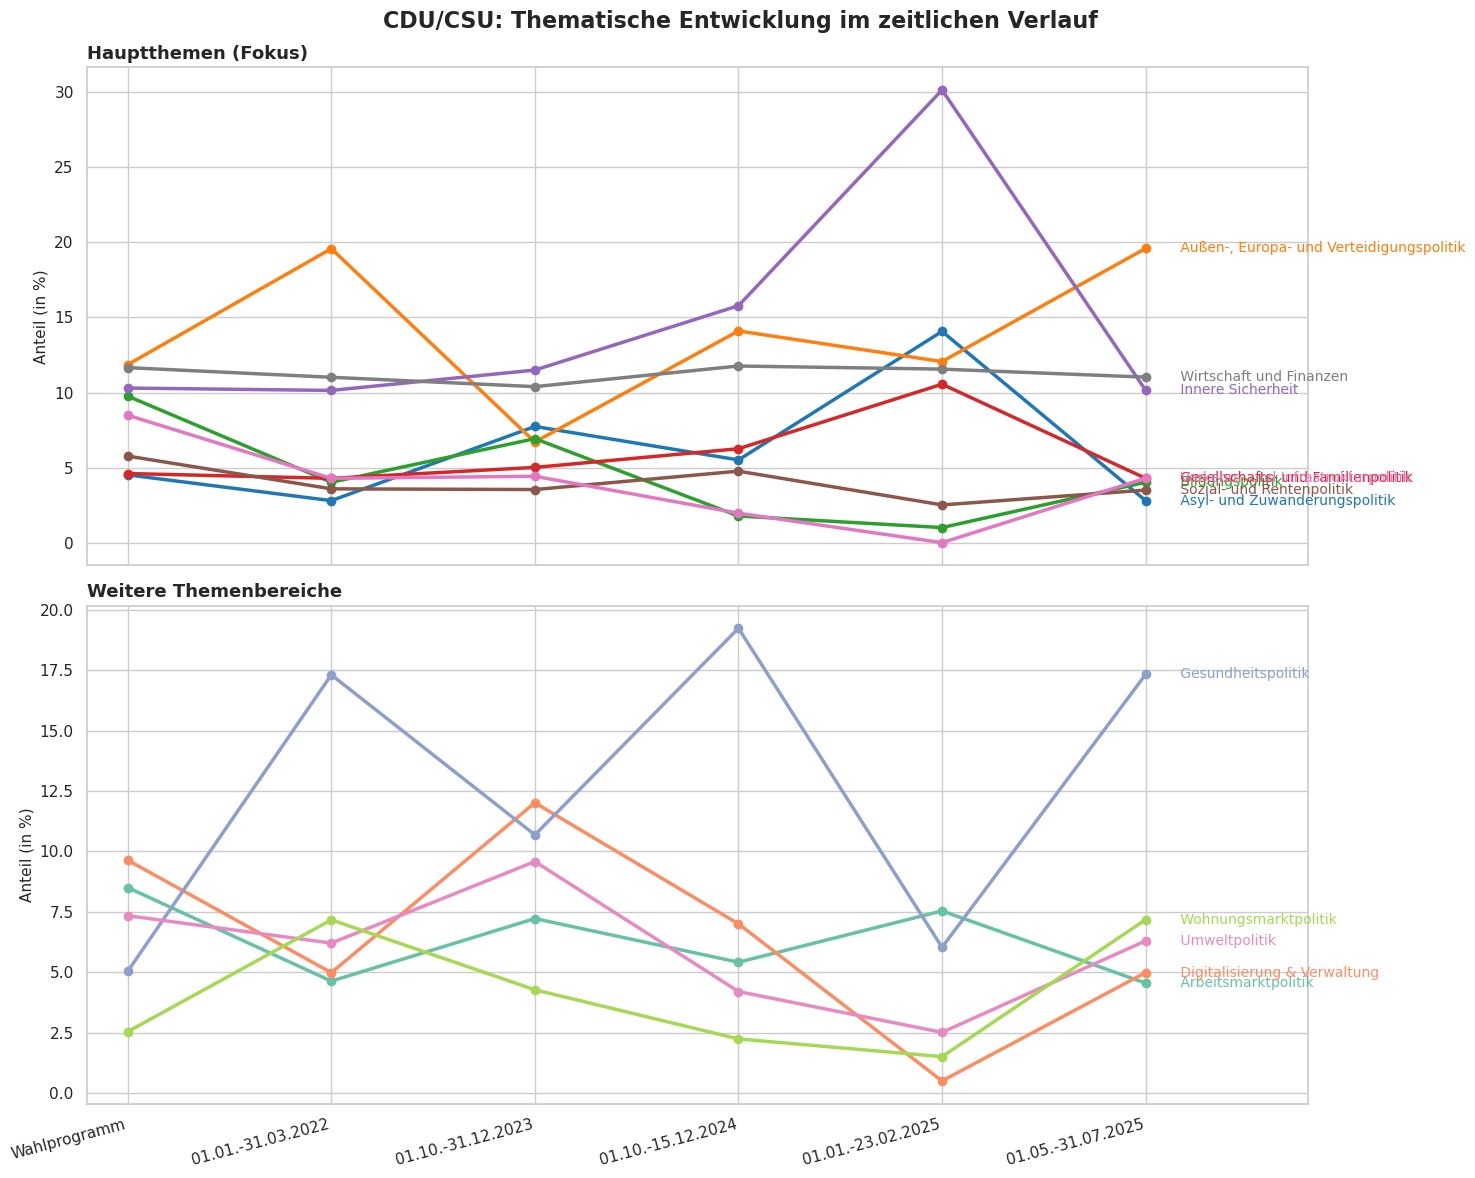

In [27]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

stoppwörter = ['90', '90die', 'aber', 'abgeordnete', 'absolut', 'afd', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also',
    'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer', 'anderes', 'anderm', 'andern', 'anscheinend',
    'anderr', 'anders', 'antrag', 'arbeiten', 'auch', 'ausschüsse', 'auf', 'aus', 'basis', 'bei', 'bevölkerung',
    'bin', 'bis', 'bisher', 'bist', 'bitte', 'brauchen', 'bundesregierung', 'bundestag', 'bundespräsidenten', 'bundespräsident', 'bündnis', 'cdu', 'cducsu',
    'csu', 'da', 'dafür', 'damen', 'damit', 'dank', 'danke', 'dann', 'das', 'dass', 'dasselbe', 'dazu', 'dr',
    'daß', 'debatte', 'definitiv', 'dein', 'deine', 'deinem', 'deinen', 'deiner', 'deines', 'dem', 'demokraten', 'demokratie', 'demselben', 'den',
    'denn', 'denselben', 'der', 'derer', 'derselbe', 'derselben', 'des', 'desselben', 'dessen', 'deutschen', 'deutsch', 'deswegen', 'deshalb',
    'deutschland', 'dich', 'die', 'dies', 'diese', 'dieselbe', 'dieselben', 'diesem', 'diesen', 'dieser', 'dieses',
    'dir', 'doch', 'dort', 'du', 'durch', 'eben', 'ebene', 'ebenen', 'ein', 'eine', 'einem', 'einen', 'einer', 'ende',
    'eines', 'einig', 'einige', 'einigem', 'einigen', 'einiger', 'einiges', 'einmal', 'er', 'es', 'etwas', 'euch',
    'euer', 'eure', 'eurem', 'euren', 'eurer', 'eures', 'euro', 'faktisch', 'fdp', 'frage', 'fraktionbündnis', 'fraktion', 'frau', 'für', 'ganz', 'geehrte',
    'gegen', 'geht', 'generationen', 'gerecht', 'gerechtigkeit', 'gerade', 'gesellschaft', 'gewesen', 'grünenfraktion', 'gewissermaßen', 'gewissenhaft', 'gibt', 'gott', 'grüne', 'grünen', 'gut', 'hab', 'habe', 'haben',
    'hat', 'hatte', 'hatten', 'helfe', 'herr', 'herren', 'heute', 'hier', 'hin', 'hinter', 'hätte', 'ich', 'ihm',
    'ihn', 'ihnen', 'ihr', 'ihre', 'ihrem', 'ihren', 'ihrer', 'ihres', 'im', 'immer', 'in', 'indem', 'ins', 'international',
    'ist', 'ja', 'jahr', 'jahren', 'jede', 'jedem', 'jeden', 'jeder', 'jedes', 'jene', 'jenem', 'jenen', 'jener', 'jedermann',
    'jenes', 'jetzt', 'kann', 'kein', 'keine', 'keinem', 'keinen', 'keiner', 'keines', 'kollege', 'kollegen', 'kommen',
    'kollegin', 'kolleginnen', 'können', 'könnte', 'land', 'letzte', 'letzten', 'liebe', 'liegen', 'linke', 'machen', 'mal',
    'man', 'manche', 'manchem', 'manchen', 'mancher', 'manches', 'maßnahme', 'maßnahmen', 'mehr', 'mein', 'meine', 'möchte',
    'meinem', 'meinen', 'meiner', 'meines', 'menschen', 'merz', 'mich', 'milliarden', 'minister', 'ministerin', 'nächste', 'nächsten',
    'mir', 'mit', 'muss', 'musste', 'müssen', 'nach', 'name', 'namen', 'natürlich', 'nicht', 'nichts', 'noch', 'nun', 'nur', 'offensichtlich',
    'ob', 'oder', 'ohne', 'parlament', 'partei', 'praktisch', 'prozent', 'prozesse', 'präsident', 'präsidentin', 'quasi', 'rede', 'redner', 'rednerin',
    'regierung', 'sagen', 'scheinbar', 'schon', 'schritte', 'sehr', 'sein', 'seine', 'seinem', 'seinen', 'seiner', 'seines',
    'selbst', 'setzen', 'sich', 'sie', 'sind', 'sitzungswochen', 'so', 'solche', 'solchem', 'solchen', 'solcher', 'solches', 'soll', 'schwöre',
    'sollte', 'sondern', 'sonst', 'sowie', 'spd', 'tatsächlich', 'um', 'und', 'union', 'uns', 'unser', 'unsere', 'unserem', 'vertrauensfrage', 'vertrauen',
    'unseren', 'unseres', 'unter', 'viel', 'viele', 'vielen', 'vielleicht', 'vollkommen', 'vom', 'von', 'vor', 'wahl', 'wahlkreise', 'wahr', 'war', 'waren', 'warst', 'was',
    'weg', 'weihnachten', 'weil', 'weiter', 'welche', 'welchem', 'welchen', 'welcher', 'welches', 'weltweit', 'welt', 'wenden',
    'weltweiten', 'weniger', 'wenn', 'werde', 'werden', 'wie', 'wieder', 'will', 'wir', 'wird', 'wirklich', 'wirst', 'wo',
    'wollen', 'wollte', 'wort', 'während', 'wünsche', 'würde', 'würden', 'ziel', 'ziele', 'zu', 'zum', 'zur',
    'zwar', 'zwischen', 'über']

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Embedding-Modell und Vektorisier definieren

!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# TEST 3  # 

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=2400,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/607 [00:00<?, ?it/s]

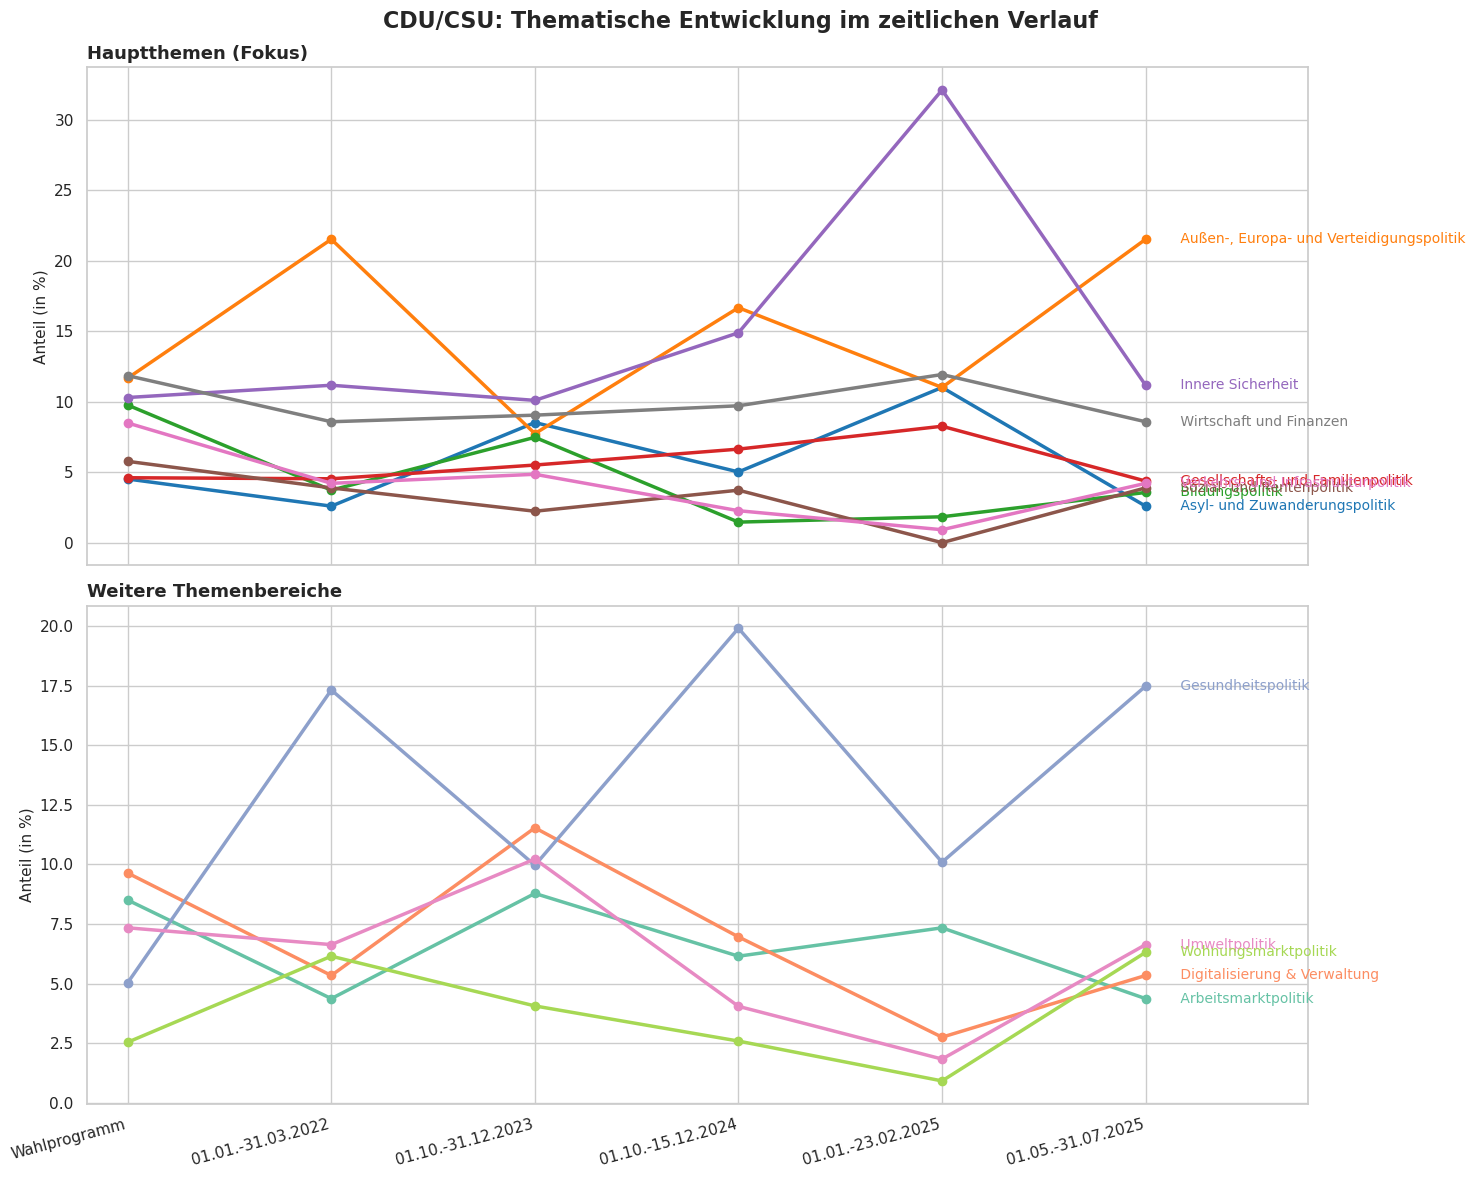

In [29]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# TEST 4  #

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=4800,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/416 [00:00<?, ?it/s]

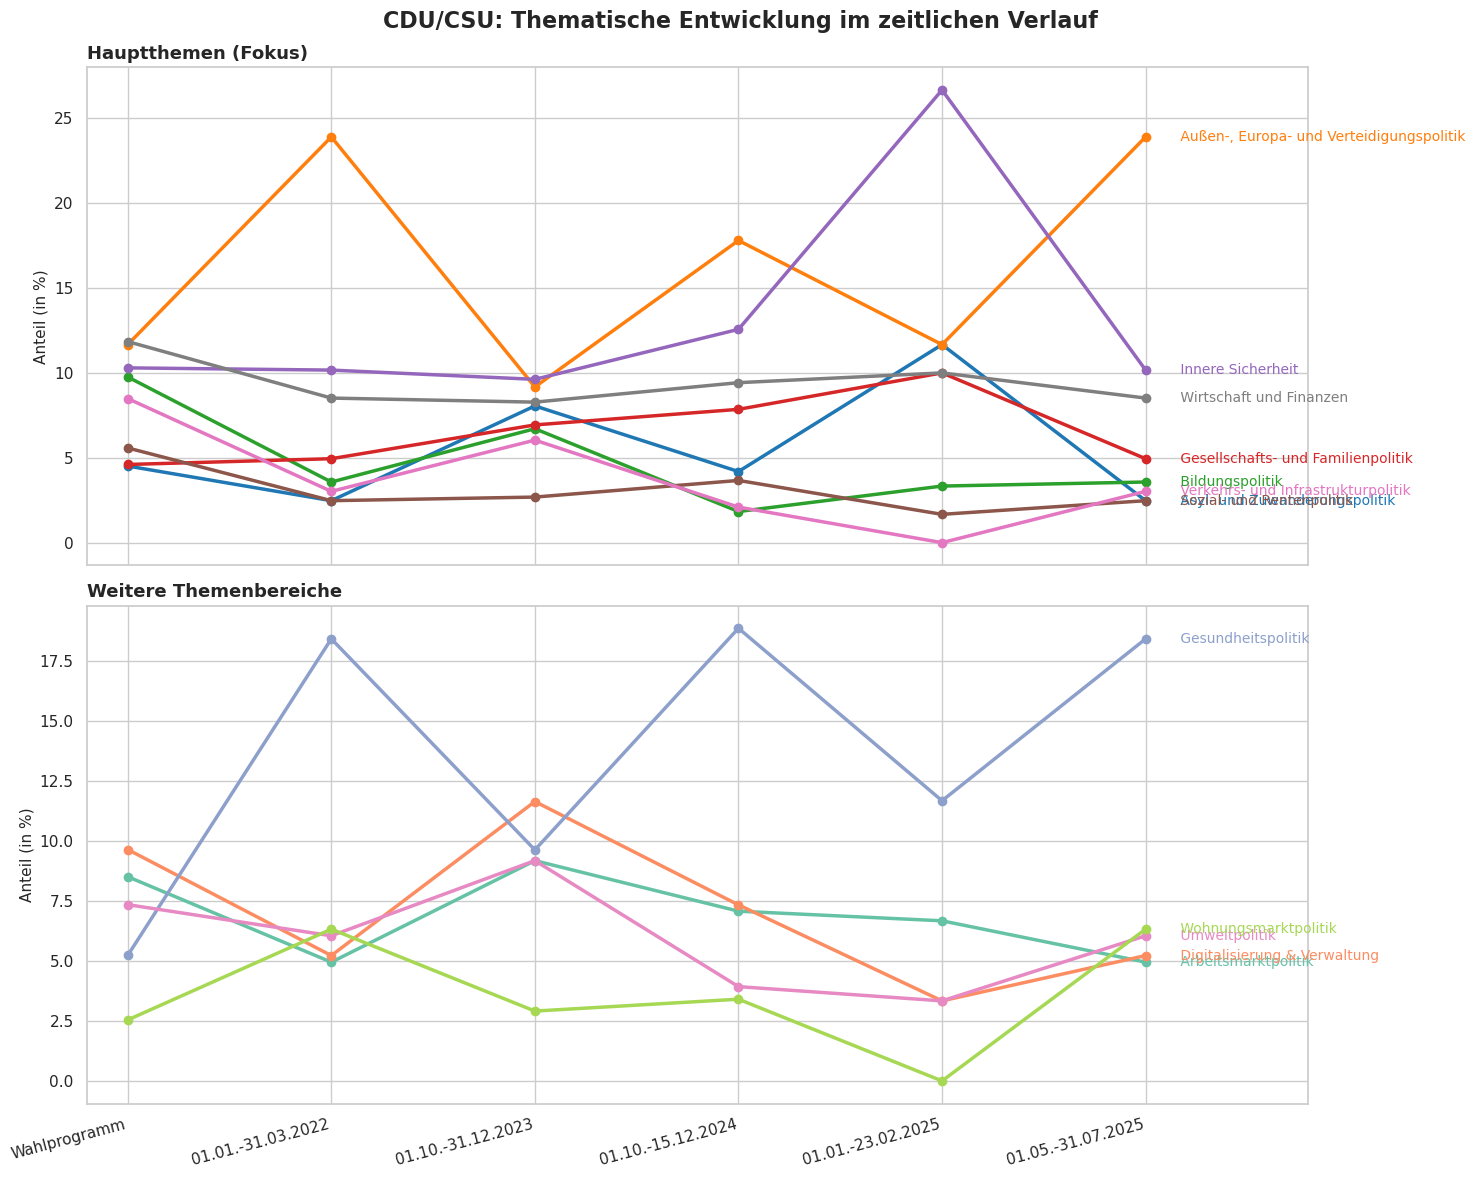

In [31]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# TEST 5  #

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=7200,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/372 [00:00<?, ?it/s]

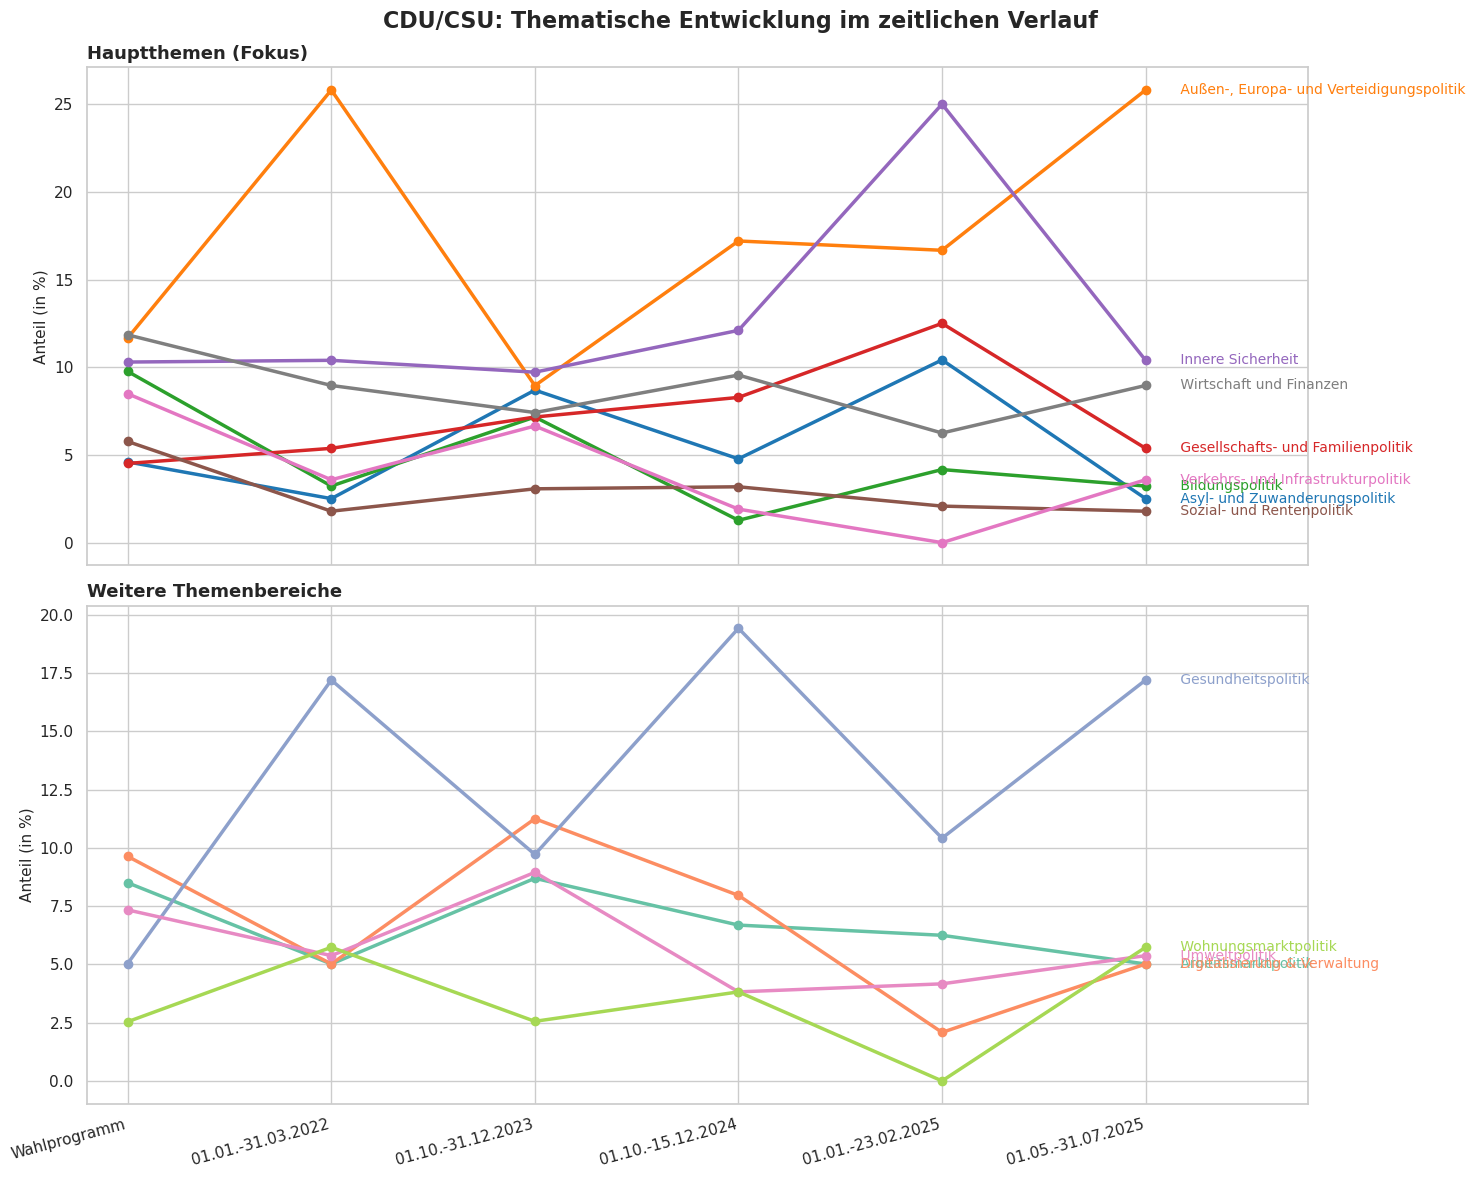

In [33]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# TEST 6  #

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=10000,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/366 [00:00<?, ?it/s]

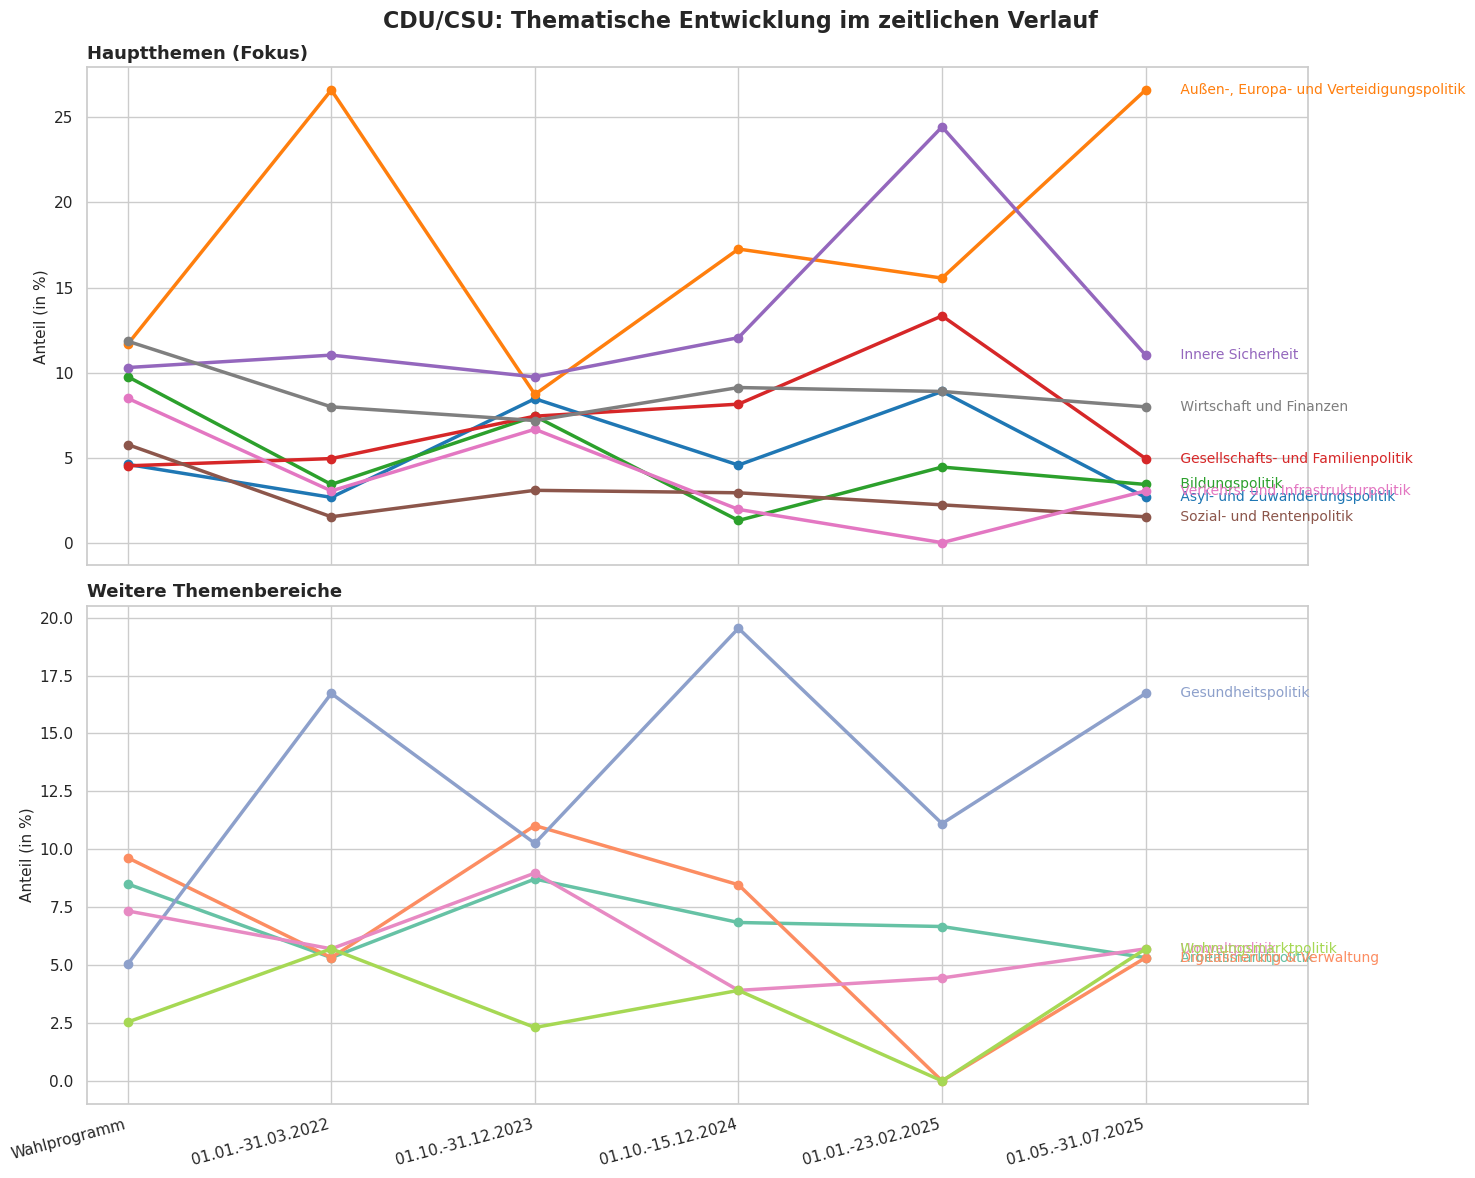

In [35]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# TEST 7  #

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=15000,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [37]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

Batches:   0%|          | 0/364 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 10.95 GiB. GPU 0 has a total capacity of 79.25 GiB of which 1.92 GiB is free. Process 7509 has 3.01 GiB memory in use. Process 10082 has 13.85 GiB memory in use. Process 15802 has 26.83 GiB memory in use. Process 17895 has 3.01 GiB memory in use. Process 20784 has 6.34 GiB memory in use. Including non-PyTorch memory, this process has 16.18 GiB memory in use. Of the allocated memory 13.93 GiB is allocated by PyTorch, and 1.75 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# TEST 8  #

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=30000,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [ ]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    "Dieses Politikfeld umfasst alle Maßnahmen zur Gewährleistung der inneren Sicherheit und der effektiven Kriminalitätsbekämpfung in Deutschland. "
    "Dazu gehören die Arbeit und Befugnisse von Sicherheitsbehörden wie dem Bundeskriminalamt oder dem Verfassungsschutz sowie die Evaluierung der Kriminalstatistik. "
    "Zudem werden gesetzliche Verschärfungen wie Messerverboote, Reformen im Waffenrecht und Debatten über die Vorratsdatenspeicherung zur Bekämpfung von Gewalt-, Clan- und organisierter Kriminalität thematisiert.",

    # 1 Asyl und Zuwanderung
    "Diese Kategorie bündelt Debatten über die nationale und europäische Migrationspolitik sowie die Regulierung von Migrationsströmen. "
    "Im Fokus stehen die rechtliche Ausgestaltung von Asylverfahren, die Steuerung irregulärer Migration und der Schutz der Außengrenzen durch Frontex. "
    "Zudem werden die gesellschaftliche Integration, Fluchtursachen sowie restriktive Maßnahmen wie Abschiebungen, Rückführungen und die Bekämpfung des Islamismus diskutiert.",

    # 2 Gesellschaft und Familie
    "Hier werden Kernfragen der modernen Gesellschafts- und Familienpolitik sowie der sozialen Gleichberechtigung behandelt. "
    "Dazu zählen staatliche Unterstützungsleistungen wie das Elterngeld, das Kindergeld, die Kindergrundsicherung und gesetzliche Kinderrrechte. "
    "Ebenso umfasst das Feld Debatten über geschlechtliche Selbstbestimmung, das Gendern, Frauenquoten und den Schutz vor Diskriminierung.",

    # 3 Verkehr und Infrastruktur
    "Dieses Feld adressiert den Ausbau, die Modernisierung und die Finanzierung der nationalen Verkehrs- und Logistikinfrastruktur. "
    "Dazu gehören die umfassende Brückensanierung, die Optimierung des Schienennetzes der Deutschen Bahn sowie der Ausbau von Straßen und Radwegen. "
    "Zentral sind zudem die politische Ausgestaltung der Verkehrswende, das Deutschlandticket, die Förderung der E-Mobilität sowie der Güter- und Fernverkehr.",

    # 4 Wohnungsmarkt
    "Diese Kategorie betrifft die ordnungspolitische Steuerung des Immobilienmarktes und die Schaffung bezahlbaren Wohnraums. "
    "Diskutiert werden wohnungspolitische Instrumente wie die Mietpreisbremse, das Wohngeld, der soziale Wohnungsbau sowie steuerliche Rahmenbedingungen wie die Grundsteuer. "
    "Zudem stehen die Vergabe von Baugenehmigungen, die Auswirkungen des Heizungsgesetzes auf Bestandsimmobilien und die Rolle großer Wohnkonzerne im Fokus.",

    # 5 Gesundheit
    "Dieses Thema umfasst die Struktur, Finanzierung und Reformierung des nationalen Gesundheitssystems und der Pflegeversicherung. "
    "Dazu gehören die Krankenhausreform, die Sicherstellung der medizinischen Gesundheitsversorgung im ländlichen Raum sowie die Digitalisierung über die elektronische Patientenakte. "
    "Ebenso werden der Pflegenotstand, die wirtschaftliche Lage von Apotheken und Arztpraxen sowie ethische Debatten wie die Regelung von Schwangerschaftsabbrüchen behandelt.",

    # 6 Bildung
    "Hier werden die Rahmenbedingungen des nationalen Bildungs- und Wissenschaftssystems sowie die Forschungsförderung thematisiert. "
    "Das Spektrum reicht von der frühkindlichen Bildung in Kitas über den akuten Lehrermangel an Schulen bis hin zu den Ergebnissen internationaler Studien wie PISA. "
    "Zudem umfasst das Feld die akademische Ausbildung an Hochschulen und Universitäten, die finanzielle Unterstützung durch das BAföG sowie die duale Berufsausbildung.",

    # 7 Wirtschaft und Finanzen
    "Dieses umfassende Feld behandelt die nationale Finanz- und Wirtschaftspolitik sowie die internationale Wettbewerbsfähigkeit des Standorts. "
    "Im Mittelpunkt stehen makroökonomische Leitplanken wie die Einhaltung der Schuldenbremse, die Aufstellung des Haushaltsplans, der Abbau von Subventionen sowie Steuererleichterungen für Unternehmen. "
    "Es adressiert die wirtschaftliche Lage von Industrie, Mittelstand, Handwerk und Betrieben, die Stabilisierung von Lieferketten sowie Fragen des Freihandels.",

    # 8 Digitalisierung und Verwaltung
    "Diese Kategorie bündelt alle Bestrebungen zur digitalen Transformation von Staat, Wirtschaft und Gesellschaft sowie die Verwaltungsmodernisierung. "
    "Zentrale Themen sind der flächendeckende Breitband- und Glasfaserausbau, staatliche IT-Infrastrukturen über das Onlinezugangsgesetz sowie Maßnahmen zur Cybersecurity. "
    "Ein weiterer Schwerpunkt liegt auf der Entbürokratisierung, der Beschleunigung von Genehmungsverfahren und dem Einsatz künstlicher Intelligenz.",

    # 9 Außen Europa Verteidigung
    "Dieses Politikfeld umfasst die deutsche Außen-, Sicherheits- und Verteidigungspolitik im globalen und europäischen Kontext. "
    "Dazu gehören die materielle und personelle Stärkung der Bundeswehr, Bündnisverpflichtungen innerhalb der NATO sowie die diplomatischen Beziehungen zu Partnern wie den USA, Frankreich oder Polen. "
    "Ebenso werden geopolitische Krisenherde, die Unterstützung der Ukraine, der Nahost-Konflikt sowie die Außenwirtschaftspolitik gegenüber China behandelt.",

    # 10 Arbeitsmarkt
    "Hier stehen die Regulierung des Arbeitsmarktes, die Fachkräftesicherung und die steuerliche Entlastung von Erwerbseinkommen im Fokus. "
    "Diskutiert werden arbeitsmarktpolitische Instrumente wie der gesetzliche Mindestlohn, der Tarifvertrag, das Arbeitszeitgesetz und Regelungen zum Kurzarbeitergeld. "
    "Zudem werden Maßnahmen gegen den Fachkräftemangel, die Fachkräfteeinwanderung sowie die Anpassung der Einkommensteuer zur Schaffung von Erwerbsanreizen verhandelt.",

    # 11 Sozial und Rente
    "Dieses Feld widmet sich der langfristigen Stabilisierung und Finanzierung der sozialen Sicherungssysteme in Deutschland. "
    "Im Vordergrund stehen die Reform des Rentensystems, die Beitragsstabilität, das Rentenniveau sowie das gesetzliche Renteneintrittsalter. "
    "Ebenso werden staatliche Fürsorgeleistungen wie das Bürgergeld oder die Grundsicherung zur Bekämpfung von Armut sowie Fragen der privaten und betrieblichen Altersvorsorge thematisiert.",

    # 12 Umwelt
    "Diese Kategorie behandelt den Natur- und Artenschutz sowie die politischen Maßnahmen zur Bewältigung des Klimawandels. "
    "Zentral sind das Erreichen nationaler Klimaziele, die Reduzierung von Treibhausgasen und die Ausgestaltung des europäischen Emissionshandels (CO2-Zertifikate). "
    "Zudem umfasst das Feld die technologische Umsetzung der Energiewende, den Ausbau erneuerbarer Energien wie Windkraft sowie den Ausstieg aus fossilen Verbrennermotoren."
]

seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
#plt.savefig('cdu_themen_verlauf_TEST.jpg', dpi=300, bbox_inches='tight')
plt.show()